<a href="https://colab.research.google.com/github/Vickramabharathi/CSA6001-Cybersecurity-Incident-Handling-and-Response/blob/main/CSA6001_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        BUSINESS CONTINUITY & DISASTER RECOVERY
                 CYBERSECURITY INCIDENT

RECOVERY PRIORITY PLAN
----------------------------------------------------------------------
                  Service      Priority  Priority_Score  RTO   RPO  Recovery_Time  Data_Loss RTO_Status RPO_Status Overall_Status
Identity & Authentication P1 - Critical             125  0.5  0.25            0.4       0.10       PASS       PASS           PASS
            Core Database P1 - Critical             125  1.0  0.25            0.8       0.20       PASS       PASS           PASS
 Customer Web Application P1 - Critical             100  1.0  0.25            0.9       0.15       PASS       PASS           PASS
          Payment Service P1 - Critical             100  1.0  0.25            0.7       0.20       PASS       PASS           PASS
            DNS / Network P1 - Critical             100  1.0  0.50            0.6       0.00       PASS       PASS           PASS
      Security Monitoring     P2 - Hi

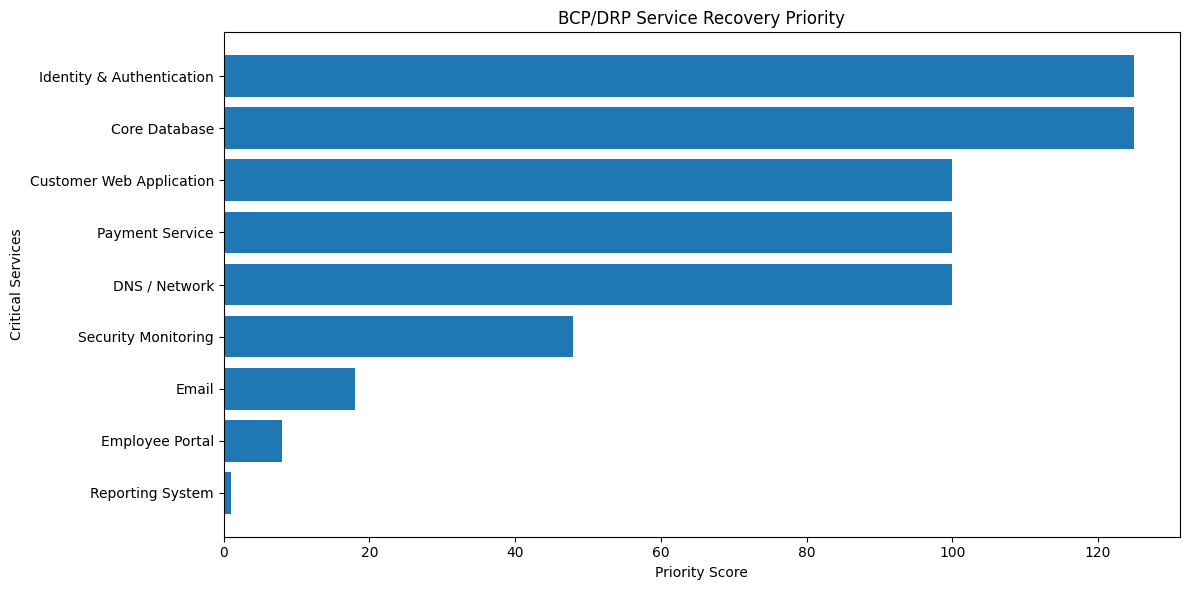

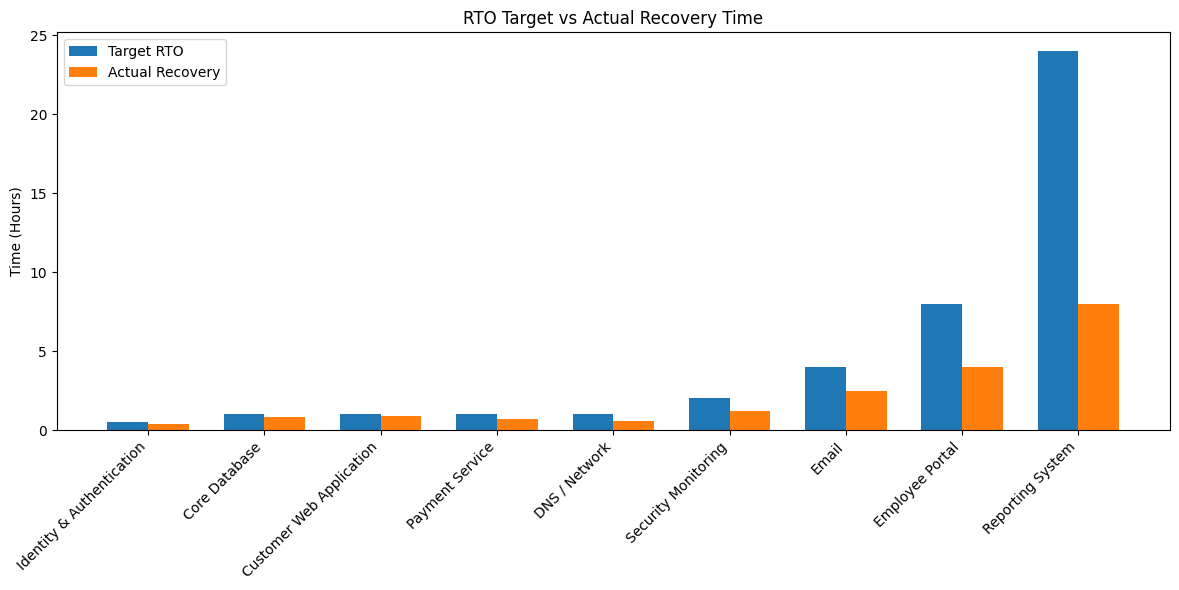

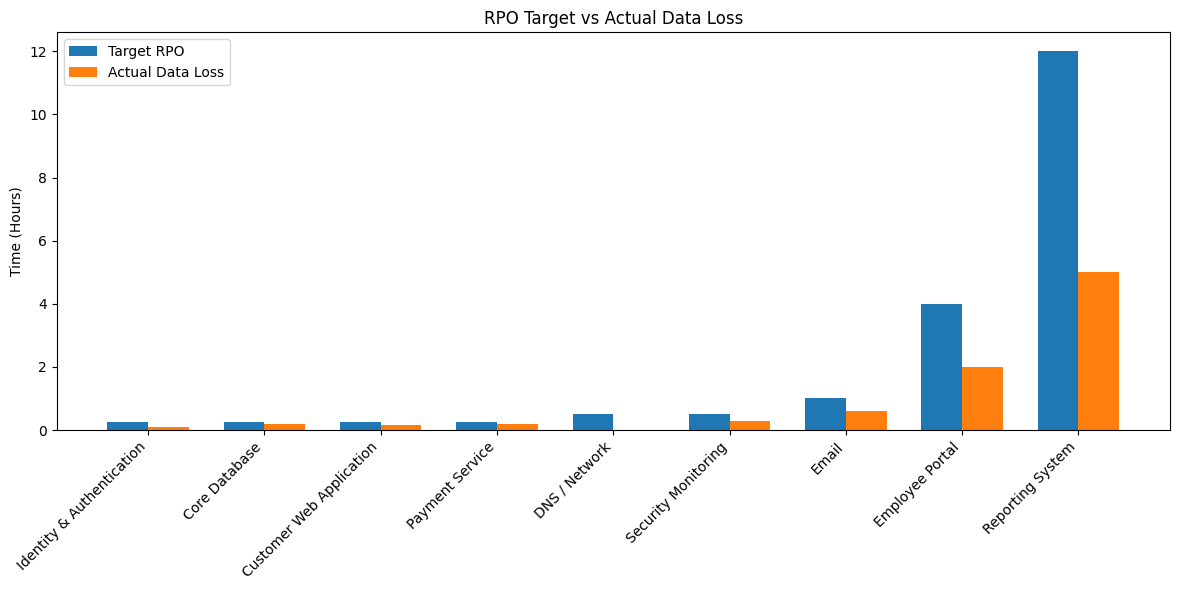

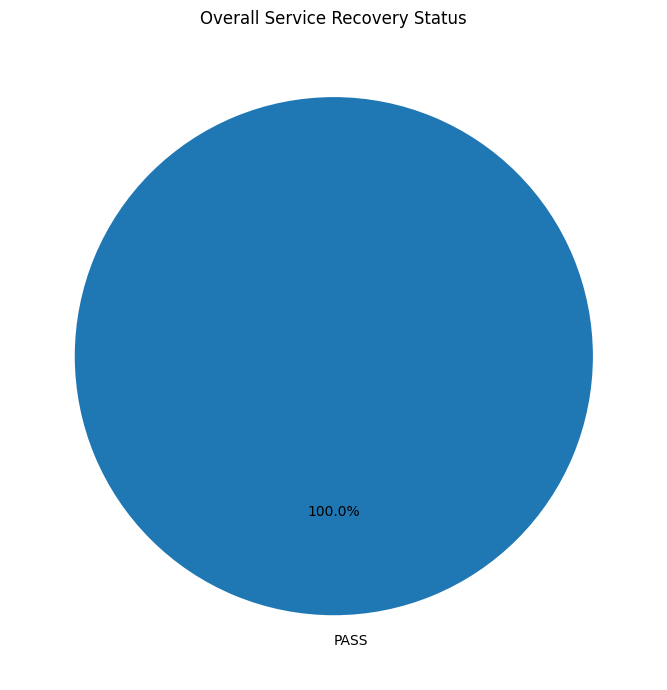

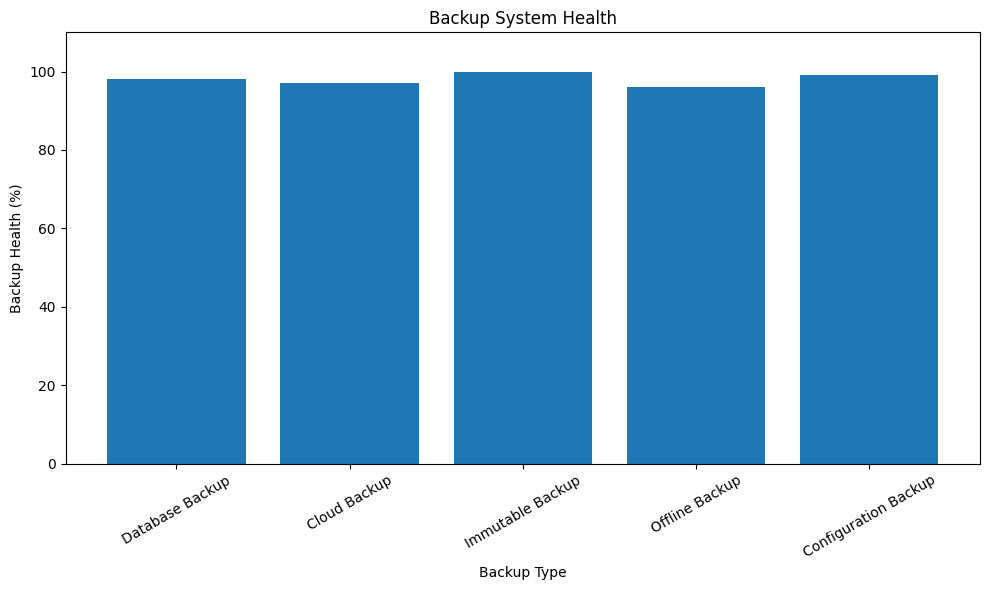

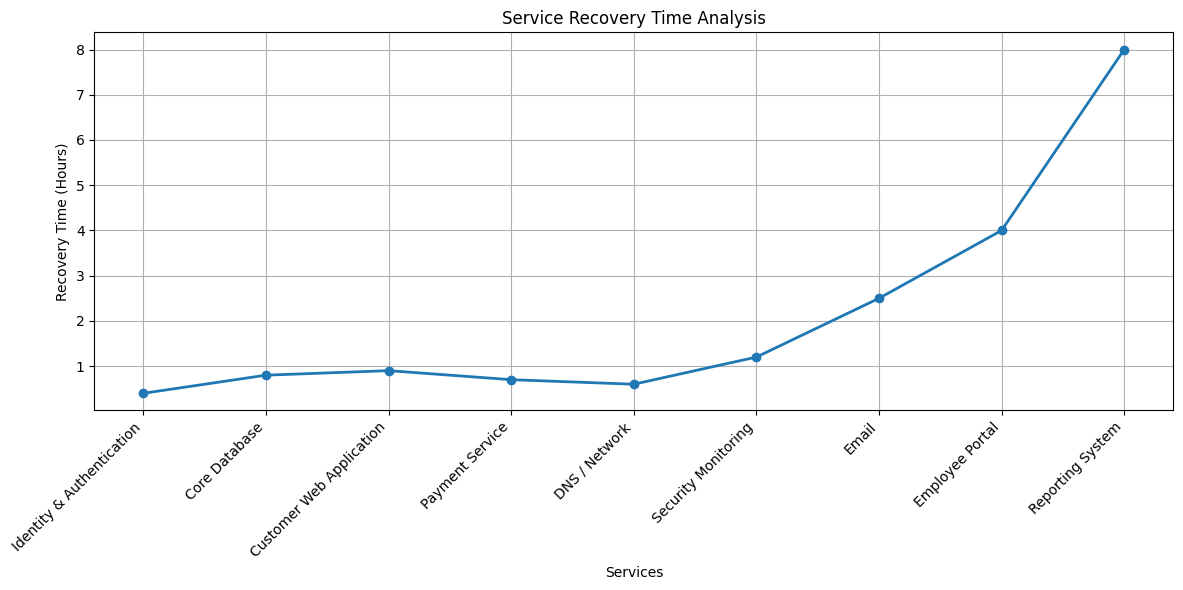



                    RECOVERY TIMELINE
 Time                   Activity
00:00       Cyberattack Detected
00:05          SOC Investigation
00:10          Incident Declared
00:15  Affected Systems Isolated
00:25              BCP Activated
00:30   DR Environment Activated
00:40 Identity Services Restored
00:55  Database Recovery Started
01:10 Core Applications Restored
01:20        Security Validation
01:30  Business Services Resumed


                   BACKUP VALIDATION
Database Backup           98%    HEALTHY
Cloud Backup              97%    HEALTHY
Immutable Backup          100%    HEALTHY
Offline Backup            96%    HEALTHY
Configuration Backup      99%    HEALTHY


                    DR READINESS
Average Backup Health : 98.00%
RTO Compliance        : 100.00%
RPO Compliance        : 100.00%
Recovery Compliance   : 100.00%
DR Readiness Score    : 99.60%
DR STATUS             : EXCELLENT


                  IMPLEMENTATION COMPLETE

Generated files:
1. 01_Recovery_Priority.png
2.

In [2]:
# ==============================================================
# BCP AND DRP STRATEGY IMPLEMENTATION
# Cybersecurity Incident Recovery Simulation
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("=" * 70)
print("        BUSINESS CONTINUITY & DISASTER RECOVERY")
print("                 CYBERSECURITY INCIDENT")
print("=" * 70)

# --------------------------------------------------------------
# 1. SERVICE DATA
# --------------------------------------------------------------

services = [
    ["Identity & Authentication", 5, 5, 5, 0.5, 0.25, 0.40, 0.10],
    ["Core Database",             5, 5, 5, 1.0, 0.25, 0.80, 0.20],
    ["Customer Web Application",  5, 4, 5, 1.0, 0.25, 0.90, 0.15],
    ["Payment Service",           5, 4, 5, 1.0, 0.25, 0.70, 0.20],
    ["DNS / Network",             4, 5, 5, 1.0, 0.50, 0.60, 0.00],
    ["Security Monitoring",      4, 3, 4, 2.0, 0.50, 1.20, 0.30],
    ["Email",                    3, 2, 3, 4.0, 1.00, 2.50, 0.60],
    ["Employee Portal",          2, 2, 2, 8.0, 4.00, 4.00, 2.00],
    ["Reporting System",         1, 1, 1, 24.0, 12.00, 8.00, 5.00]
]

columns = [
    "Service",
    "Impact",
    "Dependency",
    "Urgency",
    "RTO",
    "RPO",
    "Recovery_Time",
    "Data_Loss"
]

df = pd.DataFrame(services, columns=columns)

# --------------------------------------------------------------
# 2. CALCULATE PRIORITY SCORE
# --------------------------------------------------------------

df["Priority_Score"] = (
    df["Impact"] *
    df["Dependency"] *
    df["Urgency"]
)

# --------------------------------------------------------------
# 3. ASSIGN RECOVERY PRIORITY
# --------------------------------------------------------------

def priority(score):

    if score >= 100:
        return "P1 - Critical"

    elif score >= 40:
        return "P2 - High"

    elif score >= 10:
        return "P3 - Medium"

    else:
        return "P4 - Low"


df["Priority"] = df["Priority_Score"].apply(priority)

# --------------------------------------------------------------
# 4. RTO VALIDATION
# --------------------------------------------------------------

df["RTO_Status"] = np.where(
    df["Recovery_Time"] <= df["RTO"],
    "PASS",
    "FAIL"
)

# --------------------------------------------------------------
# 5. RPO VALIDATION
# --------------------------------------------------------------

df["RPO_Status"] = np.where(
    df["Data_Loss"] <= df["RPO"],
    "PASS",
    "FAIL"
)

# --------------------------------------------------------------
# 6. OVERALL STATUS
# --------------------------------------------------------------

df["Overall_Status"] = np.where(
    (df["RTO_Status"] == "PASS") &
    (df["RPO_Status"] == "PASS"),
    "PASS",
    "REVIEW"
)

# --------------------------------------------------------------
# 7. SORT BY RECOVERY PRIORITY
# --------------------------------------------------------------

df = df.sort_values(
    by="Priority_Score",
    ascending=False
)

# --------------------------------------------------------------
# 8. PRINT RECOVERY PLAN
# --------------------------------------------------------------

print("\nRECOVERY PRIORITY PLAN")
print("-" * 70)

print(
    df[
        [
            "Service",
            "Priority",
            "Priority_Score",
            "RTO",
            "RPO",
            "Recovery_Time",
            "Data_Loss",
            "RTO_Status",
            "RPO_Status",
            "Overall_Status"
        ]
    ].to_string(index=False)
)

# --------------------------------------------------------------
# 9. RTO / RPO STATISTICS
# --------------------------------------------------------------

total = len(df)

rto_pass = (df["RTO_Status"] == "PASS").sum()
rpo_pass = (df["RPO_Status"] == "PASS").sum()
overall_pass = (df["Overall_Status"] == "PASS").sum()

rto_percentage = (rto_pass / total) * 100
rpo_percentage = (rpo_pass / total) * 100
overall_percentage = (overall_pass / total) * 100

print("\n")
print("=" * 70)
print("                 RECOVERY PERFORMANCE")
print("=" * 70)

print(f"Total Services       : {total}")
print(f"RTO Compliance       : {rto_percentage:.2f}%")
print(f"RPO Compliance       : {rpo_percentage:.2f}%")
print(f"Overall Compliance   : {overall_percentage:.2f}%")

# --------------------------------------------------------------
# 10. GRAPH 1 - RECOVERY PRIORITY SCORE
# --------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.barh(
    df["Service"],
    df["Priority_Score"]
)

plt.xlabel("Priority Score")
plt.ylabel("Critical Services")
plt.title("BCP/DRP Service Recovery Priority")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "01_Recovery_Priority.png",
    dpi=300
)

plt.show()

# --------------------------------------------------------------
# 11. GRAPH 2 - RTO VS ACTUAL RECOVERY TIME
# --------------------------------------------------------------

plt.figure(figsize=(12, 6))

x = np.arange(len(df))
width = 0.35

plt.bar(
    x - width / 2,
    df["RTO"],
    width,
    label="Target RTO"
)

plt.bar(
    x + width / 2,
    df["Recovery_Time"],
    width,
    label="Actual Recovery"
)

plt.xticks(
    x,
    df["Service"],
    rotation=45,
    ha="right"
)

plt.ylabel("Time (Hours)")
plt.title("RTO Target vs Actual Recovery Time")

plt.legend()

plt.tight_layout()

plt.savefig(
    "02_RTO_Validation.png",
    dpi=300
)

plt.show()

# --------------------------------------------------------------
# 12. GRAPH 3 - RPO VS ACTUAL DATA LOSS
# --------------------------------------------------------------

plt.figure(figsize=(12, 6))

x = np.arange(len(df))
width = 0.35

plt.bar(
    x - width / 2,
    df["RPO"],
    width,
    label="Target RPO"
)

plt.bar(
    x + width / 2,
    df["Data_Loss"],
    width,
    label="Actual Data Loss"
)

plt.xticks(
    x,
    df["Service"],
    rotation=45,
    ha="right"
)

plt.ylabel("Time (Hours)")
plt.title("RPO Target vs Actual Data Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    "03_RPO_Validation.png",
    dpi=300
)

plt.show()

# --------------------------------------------------------------
# 13. GRAPH 4 - SERVICE RECOVERY STATUS
# --------------------------------------------------------------

status_count = df["Overall_Status"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    status_count,
    labels=status_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Service Recovery Status")

plt.tight_layout()

plt.savefig(
    "04_Recovery_Status.png",
    dpi=300
)

plt.show()

# --------------------------------------------------------------
# 14. GRAPH 5 - BACKUP HEALTH
# --------------------------------------------------------------

backup_data = {
    "Backup Type": [
        "Database Backup",
        "Cloud Backup",
        "Immutable Backup",
        "Offline Backup",
        "Configuration Backup"
    ],

    "Health": [
        98,
        97,
        100,
        96,
        99
    ]
}

backup_df = pd.DataFrame(backup_data)

plt.figure(figsize=(10, 6))

plt.bar(
    backup_df["Backup Type"],
    backup_df["Health"]
)

plt.ylabel("Backup Health (%)")
plt.xlabel("Backup Type")
plt.title("Backup System Health")

plt.ylim(0, 110)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "05_Backup_Health.png",
    dpi=300
)

plt.show()

# --------------------------------------------------------------
# 15. GRAPH 6 - SERVICE RECOVERY TIME
# --------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    df["Service"],
    df["Recovery_Time"],
    marker="o",
    linewidth=2
)

plt.xlabel("Services")
plt.ylabel("Recovery Time (Hours)")
plt.title("Service Recovery Time Analysis")

plt.xticks(rotation=45, ha="right")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "06_Recovery_Time_Analysis.png",
    dpi=300
)

plt.show()

# --------------------------------------------------------------
# 16. RECOVERY TIMELINE
# --------------------------------------------------------------

timeline = [
    ["00:00", "Cyberattack Detected"],
    ["00:05", "SOC Investigation"],
    ["00:10", "Incident Declared"],
    ["00:15", "Affected Systems Isolated"],
    ["00:25", "BCP Activated"],
    ["00:30", "DR Environment Activated"],
    ["00:40", "Identity Services Restored"],
    ["00:55", "Database Recovery Started"],
    ["01:10", "Core Applications Restored"],
    ["01:20", "Security Validation"],
    ["01:30", "Business Services Resumed"]
]

timeline_df = pd.DataFrame(
    timeline,
    columns=["Time", "Activity"]
)

print("\n")
print("=" * 70)
print("                    RECOVERY TIMELINE")
print("=" * 70)

print(timeline_df.to_string(index=False))

# --------------------------------------------------------------
# 17. BACKUP VALIDATION
# --------------------------------------------------------------

print("\n")
print("=" * 70)
print("                   BACKUP VALIDATION")
print("=" * 70)

for backup, health in zip(
    backup_df["Backup Type"],
    backup_df["Health"]
):

    if health >= 95:
        status = "HEALTHY"

    elif health >= 80:
        status = "WARNING"

    else:
        status = "CRITICAL"

    print(
        f"{backup:<25} {health}%    {status}"
    )

# --------------------------------------------------------------
# 18. DR READINESS SCORE
# --------------------------------------------------------------

backup_score = backup_df["Health"].mean()

dr_readiness = (
    (rto_percentage * 0.35) +
    (rpo_percentage * 0.35) +
    (backup_score * 0.20) +
    (overall_percentage * 0.10)
)

print("\n")
print("=" * 70)
print("                    DR READINESS")
print("=" * 70)

print(f"Average Backup Health : {backup_score:.2f}%")
print(f"RTO Compliance        : {rto_percentage:.2f}%")
print(f"RPO Compliance        : {rpo_percentage:.2f}%")
print(f"Recovery Compliance   : {overall_percentage:.2f}%")
print(f"DR Readiness Score    : {dr_readiness:.2f}%")

if dr_readiness >= 90:

    print("DR STATUS             : EXCELLENT")

elif dr_readiness >= 75:

    print("DR STATUS             : GOOD")

elif dr_readiness >= 60:

    print("DR STATUS             : NEEDS IMPROVEMENT")

else:

    print("DR STATUS             : CRITICAL")

# --------------------------------------------------------------
# 19. SAVE COMPLETE REPORT
# --------------------------------------------------------------

df.to_csv(
    "BCP_DRP_Recovery_Report.csv",
    index=False
)

timeline_df.to_csv(
    "BCP_DRP_Recovery_Timeline.csv",
    index=False
)

backup_df.to_csv(
    "BCP_DRP_Backup_Health.csv",
    index=False
)

# --------------------------------------------------------------
# 20. FINAL REPORT
# --------------------------------------------------------------

print("\n")
print("=" * 70)
print("                  IMPLEMENTATION COMPLETE")
print("=" * 70)

print("\nGenerated files:")

print("1. 01_Recovery_Priority.png")
print("2. 02_RTO_Validation.png")
print("3. 03_RPO_Validation.png")
print("4. 04_Recovery_Status.png")
print("5. 05_Backup_Health.png")
print("6. 06_Recovery_Time_Analysis.png")
print("7. BCP_DRP_Recovery_Report.csv")
print("8. BCP_DRP_Recovery_Timeline.csv")
print("9. BCP_DRP_Backup_Health.csv")

print("\nBCP and DRP simulation completed successfully.")